# 实验二：卷积神经网络


### 开发环境
* 本文件对示例代码进行了部分修改
* 部分变量定义与原文件不符合属于正常现象！！！


### 一、实验简介
本实验的目的是搭建卷积神经网络(CNN)来解决图像分类问题，将搭建一个简易的卷积神经网络对一个简单的实物数据集进行识别和分类。
在开始实验前需要安装好python以及相应的集成开发环境IDE，并安装好需要用到的python库。
本实验的示例中用到的python库主要有Keras、Numpy、matplotlib、tensorflow。


In [1]:
# 使用tar命令直接解压
!tar -xzvf ./cifar-10-python.tar.gz -C 

# 查看解压结果
!ls -la ./cifar-10-python/cifar-10-batches-py/

cifar-10-batches-py/
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/data_batch_1
total 181884
drwxr-xr-x 2 2156 1103     4096 Jun  5  2009 .
drwxr-xr-x 6 root root     4096 Apr 14 18:45 ..
-rw-r--r-- 1 2156 1103      158 Mar 31  2009 batches.meta
-rw-r--r-- 1 2156 1103 31035704 Mar 31  2009 data_batch_1
-rw-r--r-- 1 2156 1103 31035320 Mar 31  2009 data_batch_2
-rw-r--r-- 1 2156 1103 31035999 Mar 31  2009 data_batch_3
-rw-r--r-- 1 2156 1103 31035696 Mar 31  2009 data_batch_4
-rw-r--r-- 1 2156 1103 31035623 Mar 31  2009 data_batch_5
-rw-r--r-- 1 2156 1103       88 Jun  5  2009 readme.html
-rw-r--r-- 1 2156 1103 31035526 Mar 31  2009 test_batch


In [2]:
!nvidia-smi
import os
import pickle
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
# 检查 GPU
print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

# 添加：输出GPU和CUDA信息
print("\n=== GPU和CUDA信息 ===")
# 检查是否有GPU可用
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ 检测到 {len(gpus)} 个GPU设备")
    for gpu in gpus:
        print(f"  - {gpu}")
    
    # 检查CUDA支持
    try:
        # 检查是否构建了CUDA支持
        cuda_built = tf.test.is_built_with_cuda()
        print(f"TensorFlow是否构建了CUDA支持: {cuda_built}")
        
        # 获取CUDA版本（较新的TensorFlow版本使用build_info）
        try:
            # TensorFlow 2.x
            from tensorflow.python.platform import build_info
            cuda_version = build_info.build_info.get('cuda_version', '未知')
            cudnn_version = build_info.build_info.get('cudnn_version', '未知')
            print(f"CUDA版本: {cuda_version}")
            print(f"cuDNN版本: {cudnn_version}")
        except (ImportError, AttributeError):
            # 回退到sysconfig方法
            try:
                cuda_version = tf.sysconfig.get_build_info().get('cuda_version', '未知')
                cudnn_version = tf.sysconfig.get_build_info().get('cudnn_version', '未知')
                print(f"CUDA版本: {cuda_version}")
                print(f"cuDNN版本: {cudnn_version}")
            except:
                print("CUDA/cuDNN版本: 无法获取详细信息")
        
        # 可选：获取GPU计算能力
        for gpu in gpus:
            try:
                details = tf.config.experimental.get_device_details(gpu)
                if details:
                    compute_capability = details.get('compute_capability', '未知')
                    print(f"GPU计算能力: {compute_capability}")
            except:
                pass
        
    except Exception as e:
        print(f"获取CUDA信息时出错: {e}")
else:
    print("❌ 未检测到GPU设备，将使用CPU运行")
    # 检查CUDA支持
    try:
        cuda_built = tf.test.is_built_with_cuda()
        print(f"TensorFlow是否构建了CUDA支持: {cuda_built}")
    except:
        pass

# 可选：检查可用的内存限制
try:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
        print(f"已为 {gpu.name} 启用内存增长")
except:
    pass

"""# 设置内存限制
try:
    for gpu in gpus:
        # 限制GPU内存使用（例如4GB）
        tf.config.set_logical_device_configuration(
            gpu,
            [tf.config.LogicalDeviceConfiguration(memory_limit=4096)]
        )
        print(f"已设置GPU内存限制: 4096 MB")
except:
    pass"""

print("=" * 30 + "\n")

Tue Apr 14 18:47:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.163.01             Driver Version: 550.163.01     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A10                     Off |   00000000:00:09.0 Off |                  Off |
|  0%   54C    P0             61W /  150W |   22738MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

2026-04-14 18:47:53.964638: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-14 18:47:53.998716: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-14 18:47:53.998739: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-14 18:47:53.998758: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-14 18:47:54.004848: I tensorflow/core/platform/cpu_feature_g

TensorFlow version: 2.14.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

=== GPU和CUDA信息 ===
✅ 检测到 1 个GPU设备
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
TensorFlow是否构建了CUDA支持: True
CUDA版本: 11.8
cuDNN版本: 8
GPU计算能力: (8, 6)
已为 /physical_device:GPU:0 启用内存增长



2026-04-14 18:47:55.786926: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-14 18:47:55.807899: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-14 18:47:55.808049: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

## 二、图像分类：多分类问题
### 2.1 CIFAR-10数据集
CIFAR-10是一个更接近普适物体的彩色图像数据集。CIFAR-10 是由Hinton 的学生Alex Krizhevsky 和Ilya Sutskever 整理的一个用于识别普适物体的小型数据集。一共包含10 个类别的彩色图片：飞机(airplane)、汽车(automobile)、鸟类(bird)、猫(cat)、鹿(deer)、狗(dog)、蛙类(frog)、马(horse)、船(ship)和卡车(truck)。

每个图片的尺寸为32×32 ，每个类别有6000个图像，数据集中一共有50000 张训练图片和10000 张测试图片。与MNIST数据集中手写数字的灰度图不同，CIFAR-10数据集中为3通道RGB彩色图片，包含训练数据、训练标签、测试数据、测试标签，大小分别为(50000, 32, 32, 3)、(50000, 1)、(10000, 32, 32, 3)、(10000, 1)。

不同于手写字符， CIFAR-10 含有的是现实世界中真实的物体，不仅噪声很大，而且物体的比例、特征都不尽相同，这为识别带来很大困难，因此相比于全连接网络，卷积神经网络(CNN)将会有比较明显的优势。不过由于图片本身复杂度高和分辨率低等原因，使用一个简单的网络进行分类准确率不会太高，在60%~80%左右均属正常。


### 2.2 导入库+读取本地的CIFAR-10数据集

In [3]:
# 检查 GPU
print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

# 本地CIFAR-10数据路径
data_dir = r"./cifar-10-python/cifar-10-batches-py"


def load_cifar_batch(filepath):
    with open(filepath, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')

    data = batch[b'data']          # shape: (10000, 3072)
    labels = batch[b'labels']      # list

    # 转成 (N, 32, 32, 3)
    data = data.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    labels = np.array(labels)

    return data, labels


# 读取训练集
train_data_list = []
train_label_list = []

for i in range(1, 6):
    batch_path = os.path.join(data_dir, f"data_batch_{i}")
    batch_data, batch_label = load_cifar_batch(batch_path)
    train_data_list.append(batch_data)
    train_label_list.append(batch_label)

train_data = np.concatenate(train_data_list, axis=0)
train_label = np.concatenate(train_label_list, axis=0)

# 读取测试集
test_data, test_label = load_cifar_batch(os.path.join(data_dir, "test_batch"))

print(f"训练数据形状: {train_data.shape}, 数据类型: {train_data.dtype}")
print(f"训练标签形状: {train_label.shape}, 数据类型: {train_label.dtype}")
print(f"测试数据形状: {test_data.shape}, 数据类型: {test_data.dtype}")
print(f"测试标签形状: {test_label.shape}, 数据类型: {test_label.dtype}")

print("Dataset is ready! ")
print("Hello Tensorflow! ")

TensorFlow version: 2.14.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
训练数据形状: (50000, 32, 32, 3), 数据类型: uint8
训练标签形状: (50000,), 数据类型: int64
测试数据形状: (10000, 32, 32, 3), 数据类型: uint8
测试标签形状: (10000,), 数据类型: int64
Dataset is ready! 
Hello Tensorflow! 


### 2.3 数据与标签预处理

In [4]:
# 对图像做把图像数据从uint8转换为float32并且归一化
x_data = train_data.astype('float32')/255.0
x_test = test_data.astype('float32')/255.0

def one_hot(label, num_classes):
    # your code here
    # 补充 one-hot 编码函数

    label_one_hot = np.eye(num_classes)[label]
    # np自动生成单位矩阵，根据label数组自动取对应行生成one_hot编码矩阵
    
    return label_one_hot

#本实验使用CIFAR-10版本，因此只有十类
num_classes = 10

# train_label才需要做one_hot编码，testlabel保持numpy数组即可
# 只是用来计算准确率的
train_label = train_label.astype('int32')
x_label = one_hot(train_label, num_classes)

test_label = test_label.astype('int32')
y_label = np.squeeze(test_label)

print(f"训练标签形状: {x_label.shape}, 标签类型: {x_label.dtype}")
print(f"测试标签形状: {y_label.shape}, 标签类型: {y_label.dtype}")

print(f'x_data.shape = {x_data.shape}')
print(f'x_test.shape = {x_test.shape}')
print(f'x_label[0:5] =\n {x_label[0:5]}')
print(f'train_label[0:5] = {train_label[0:5]}')


训练标签形状: (50000, 10), 标签类型: float64
测试标签形状: (10000,), 标签类型: int32
x_data.shape = (50000, 32, 32, 3)
x_test.shape = (10000, 32, 32, 3)
x_label[0:5] =
 [[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]
train_label[0:5] = [6 9 9 4 1]


## 三、卷积神经网络(CNN)
### 3.1 构建网络
* 在本实验中，将复用相同的总体结构，即卷积神经网络由Conv2D 层（使用relu 激活）和MaxPooling2D 层交替堆叠构成。初始输入的尺寸为(32, 32, 3)，经过两个卷积单元后变为(8, 8, 64)，经过Flatten层打平为向量后送入全连接层。

* 如果处理更大的图像和更复杂的问题，需要相应地增大网络，即再增加一些Conv2D+MaxPooling2D 的组合。这既可以增大网络容量，也可以进一步减小特征图的尺寸，使其在连接Flatten 层时尺寸不会太大。

* 该问题是一个多分类问题，所以网络最后一层是使用softmax激活函数（大小为10的Dense 层），这一层将对某个类别的概率进行编码。此外，还设置了一些dropout层，在训练过程中随机将该层的一些输出特征舍弃（设置为0），来避免过拟合。


In [5]:
cnn = Sequential()

# unit1
cnn.add(Conv2D(32, kernel_size=(3, 3), input_shape=(32, 32, 3),
               activation='relu', padding='same'))
# 注意padding为same，是填充0的等宽卷积，输出仍然为32*32（32通道）！
cnn.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'))
cnn.add(MaxPooling2D(pool_size=(2, 2), padding='same'))
cnn.add(Dropout(0.5))
# 这里做maxpooling之后，输出为16x16x32(32通道特征)

# unit2
# 编写网络的第二部分，可自行尝试增加更多的卷积层，改变通道数、激活函数等
# 以下设置仅供参考：
# 两个2D卷积层，均为64个通道，卷积核为(3, 3)，激活函数为relu，padding为same；
# 一个2D池化层，pool_size为(2, 2)，padding为same；
# 最后是Dropout层，保留概率为0.5
# your code here
# unit2
cnn.add(Conv2D(64, kernel_size=[3, 3], activation='relu', padding='same'))
cnn.add(Conv2D(64, kernel_size=[3, 3], activation='relu', padding='same'))
cnn.add(Conv2D(128, kernel_size=[3, 3], activation='relu', padding='same'))
cnn.add(MaxPooling2D(pool_size=[2, 2], padding='same'))
cnn.add(Conv2D(256, kernel_size=[3, 3], activation='relu', padding='same'))
cnn.add(MaxPooling2D(pool_size=[2, 2], padding='same'))
cnn.add(Dropout(0.4))

# unit3
cnn.add(Flatten())

cnn.add(Dense(512, activation='relu'))
cnn.add(Dropout(0.5))
cnn.add(Dense(128, activation='relu'))
cnn.add(Dropout(0.5))
cnn.add(Dense(10, activation='softmax'))

print(cnn.summary())


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 32)        9248      
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 16, 16, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 16, 16, 64)        36928     
                                                        

2026-04-14 18:47:56.353987: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-14 18:47:56.354143: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-14 18:47:56.354221: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

### 3.2 编译模型
在编译这一步，将使用Adam 优化器，学习率为0.001。因为网络最后一层是softmax激活函数，所以使用交叉熵(categorical_crossentropy)作为损失函数。


In [6]:
# 采用model.compile模型编译，设置优化器、学习率、损失函数和准确率观测
# your code here
cnn.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=5e-4,
        weight_decay=1e-4
    ),
    loss="categorical_crossentropy",
    metrics=['accuracy']
)

### 3.3 训练模型
使用32个样本组成的小批量，将模型训练50个轮次（即对train_data和y_train 两个张量中的所有样本进行50次迭代）。同时，分离出1/10的训练数据作为验证集，不对其进行训练，并且将在每个时期结束时评估此数据的损失和任何模型度量。


In [7]:
history_cnn = cnn.fit(
    x_data,
    x_label,
    epochs=100,
    batch_size=128,
    shuffle=True,
    verbose=1,
    validation_split=0.1
)

history_dict = history_cnn.history
print(f'history_dict.keys() = {history_dict.keys()}')

Epoch 1/100


2026-04-14 18:47:58.498548: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-04-14 18:47:58.676108: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8900
2026-04-14 18:47:59.522831: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f4d40002010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-14 18:47:59.522847: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A10, Compute Capability 8.6
2026-04-14 18:47:59.527019: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-14 18:47:59.609786: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster 

352/352 [==============================] - 7s 9ms/step - loss: 1.9442 - accuracy: 0.2662 - val_loss: 1.5357 - val_accuracy: 0.4322
Epoch 2/100
352/352 [==============================] - 3s 7ms/step - loss: 1.5192 - accuracy: 0.4409 - val_loss: 1.2421 - val_accuracy: 0.5464
Epoch 3/100
352/352 [==============================] - 3s 7ms/step - loss: 1.3011 - accuracy: 0.5322 - val_loss: 1.0804 - val_accuracy: 0.6174
Epoch 4/100
352/352 [==============================] - 3s 7ms/step - loss: 1.1701 - accuracy: 0.5846 - val_loss: 1.0283 - val_accuracy: 0.6336
Epoch 5/100
352/352 [==============================] - 3s 7ms/step - loss: 1.0692 - accuracy: 0.6252 - val_loss: 0.9161 - val_accuracy: 0.6812
Epoch 6/100
352/352 [==============================] - 3s 7ms/step - loss: 0.9998 - accuracy: 0.6537 - val_loss: 0.8329 - val_accuracy: 0.7116
Epoch 7/100
352/352 [==============================] - 3s 7ms/step - loss: 0.9294 - accuracy: 0.6792 - val_loss: 0.8380 - val_accuracy: 0.7120
Epoch 8/100

### 3.4  绘制损失和精度图

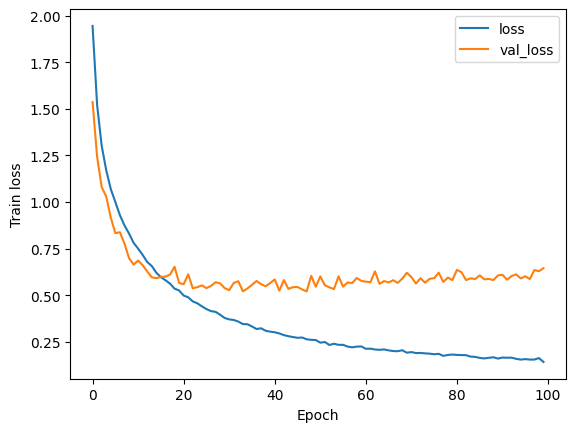

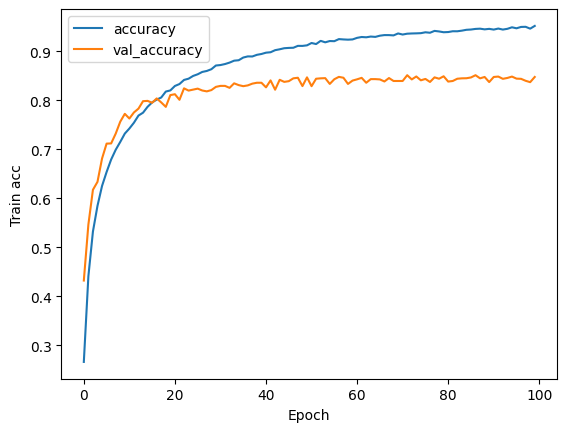

In [8]:
plt.figure(1)
plt.plot(np.array(history_cnn.history['loss']))
plt.plot(np.array(history_cnn.history['val_loss']))
plt.xlabel('Epoch')
plt.ylabel('Train loss')
plt.legend(['loss', 'val_loss'])
plt.show()

plt.figure(2)
plt.plot(np.array(history_cnn.history['accuracy']))
plt.plot(np.array(history_cnn.history['val_accuracy']))
plt.xlabel('Epoch')
plt.ylabel('Train acc')
plt.legend(['accuracy', 'val_accuracy'])
plt.show()

### 3.5 保存模型

In [9]:
os.makedirs('model', exist_ok=True)
cnn.save('model/cnn.h5')

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


### 3.6 在新数据上生成预测结果
加载保存的模型并输入测试数据得到预测结果。

In [10]:
#加载保存的模型
cnn = keras.models.load_model('model/cnn.h5')

#对测试集进行预测，以评估模型性能
test_out = cnn.predict(x_test)
print(f"输出test_out的形状为：{test_out.shape}")

#需要统计totalnum，num，accuracy
"""np.argmax()：这是NumPy库中的一个函数
其名称是 “argument of the maximum” 的缩写
它不返回最大值本身
而是返回最大值在数组中首次出现的位置（索引）
在这里就是寻找预测概率最大的位置索引，就是预测结果
"""
num = 0
total_num = x_test.shape[0]

for i in range(0,total_num):
    if np.argmax(test_out[i]) == y_label[i]:
        num += 1

print(f"共完成 {total_num} 次预测，其中 {num} 个正确!")

313/313 [==============================] - 1s 1ms/step
输出test_out的形状为：(10000, 10)
共完成 10000 次预测，其中 8311 个正确!


### 3.7 测试模型准确率
* Teacher：将10000个测试数据输入模型中，得到预测结果并计算准确率，最终得到模型的预测准确率为76.93%。
* 自己设计的CNN准确率约为83.5%(由于本实验没有确定随机种子，所以训练结果偶有波动属于正常现象)

In [11]:
accuracy = num / total_num
print(f'accuracy = {accuracy}')

accuracy = 0.8311
